# Life Expectancy Prediction


## 1. Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## 2. Loading the Dataset

In [5]:
df = pd.read_csv('Life Expectancy Data.csv')
df.head(10)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
5,Afghanistan,2010,Developing,58.8,279.0,74,0.01,79.679367,66.0,1989,...,66.0,9.20,66.0,0.1,553.328940,2883167.0,18.4,18.4,0.448,9.2
6,Afghanistan,2009,Developing,58.6,281.0,77,0.01,56.762217,63.0,2861,...,63.0,9.42,63.0,0.1,445.893298,284331.0,18.6,18.7,0.434,8.9
7,Afghanistan,2008,Developing,58.1,287.0,80,0.03,25.873925,64.0,1599,...,64.0,8.33,64.0,0.1,373.361116,2729431.0,18.8,18.9,0.433,8.7
8,Afghanistan,2007,Developing,57.5,295.0,82,0.02,10.910156,63.0,1141,...,63.0,6.73,63.0,0.1,369.835796,26616792.0,19.0,19.1,0.415,8.4
9,Afghanistan,2006,Developing,57.3,295.0,84,0.03,17.171518,64.0,1990,...,58.0,7.43,58.0,0.1,272.563770,2589345.0,19.2,19.3,0.405,8.1


In [6]:
print(f'Dataset shape: {df.shape}')
print(f'\nNumber of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

Dataset shape: (2938, 22)

Number of rows: 2938
Number of columns: 22


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [8]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [9]:
# checking column names - some might have extra spaces
print('Column names:')
for col in df.columns:
    print(f'  "{col}"')

Column names:
  "Country"
  "Year"
  "Status"
  "Life expectancy "
  "Adult Mortality"
  "infant deaths"
  "Alcohol"
  "percentage expenditure"
  "Hepatitis B"
  "Measles "
  " BMI "
  "under-five deaths "
  "Polio"
  "Total expenditure"
  "Diphtheria "
  " HIV/AIDS"
  "GDP"
  "Population"
  " thinness  1-19 years"
  " thinness 5-9 years"
  "Income composition of resources"
  "Schooling"


In [10]:
# cleaning up column names - removing leading/trailing whitespace
df.columns = df.columns.str.strip()
print('Cleaned column names:')
print(df.columns.tolist())

Cleaned column names:
['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


## 3. Exploratory Data Analysis (EDA)

### 3.1 Missing Value Analysis

In [11]:
# checking for missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False)
print('Columns with missing values:')
missing_df

Columns with missing values:


,Missing Count,Percentage
Population,652,22.191967
Hepatitis B,553,18.822328
GDP,448,15.248468
Total expenditure,226,7.692308
Alcohol,194,6.603131
Income composition of resources,167,5.684139
Schooling,163,5.547992
thinness 5-9 years,34,1.157250
thinness 1-19 years,34,1.157250
BMI,34,1.157250


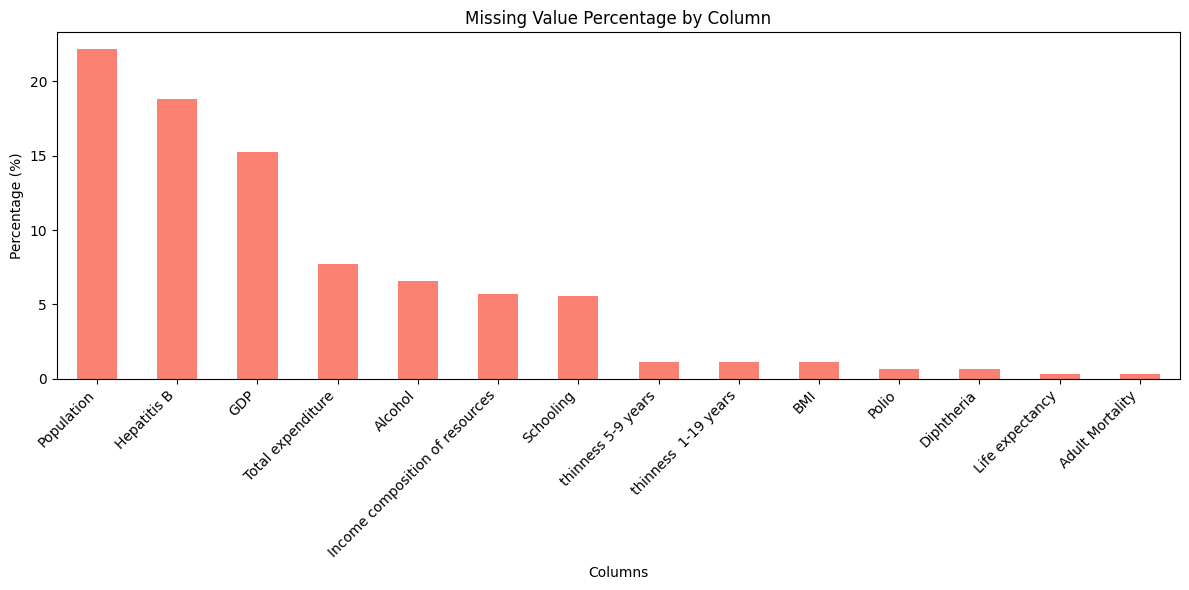

In [12]:
# visualizing missing values
plt.figure(figsize=(12, 6))
missing_df['Percentage'].plot(kind='bar', color='salmon')
plt.title('Missing Value Percentage by Column')
plt.ylabel('Percentage (%)')
plt.xlabel('Columns')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

There are several columns with missing values. We'll handle these using appropriate imputation techniques.

### 3.2 Target Variable Analysis

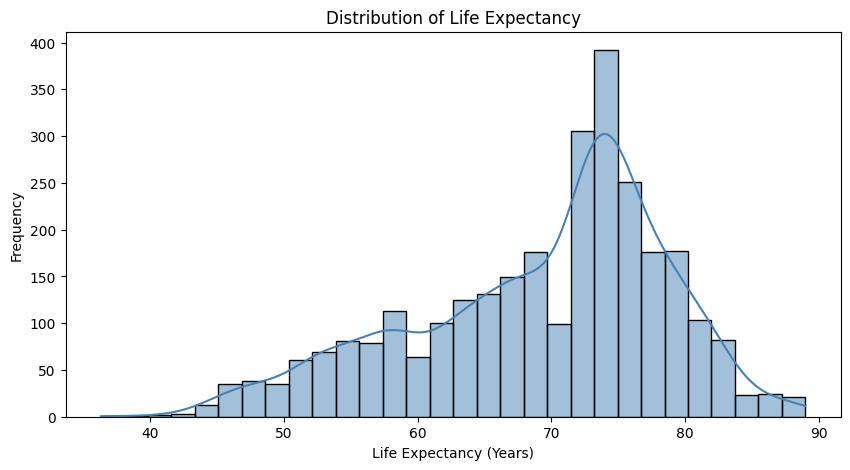

Mean Life Expectancy: 69.22
Median Life Expectancy: 72.10
Skewness: -0.6386


In [13]:
# our target variable is 'Life expectancy'
plt.figure(figsize=(10, 5))
sns.histplot(x=df['Life expectancy'], kde=True, bins=30, color='steelblue')
plt.title('Distribution of Life Expectancy')
plt.xlabel('Life Expectancy (Years)')
plt.ylabel('Frequency')
plt.show()

print(f"Mean Life Expectancy: {df['Life expectancy'].mean():.2f}")
print(f"Median Life Expectancy: {df['Life expectancy'].median():.2f}")
print(f"Skewness: {df['Life expectancy'].skew():.4f}")


The target variable looks roughly normally distributed with a slight left skew. That's good for regression.

### 3.3 Categorical vs Numerical Features

In [14]:
# checking data types
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()

print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print(f'\nNumerical columns ({len(num_cols)}): {num_cols}')

Categorical columns (2): ['Country', 'Status']

Numerical columns (20): ['Year', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


C:\Users\USSER\AppData\Local\Temp\ipykernel_21720\682601411.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [15]:
# checking unique values in categorical columns
for col in cat_cols:
    print(f'{col}: {df[col].nunique()} unique values')
    if df[col].nunique() < 10:
        print(f'  Values: {df[col].unique()}')
    print()

Country: 193 unique values

Status: 2 unique values
  Values: <ArrowStringArray>
['Developing', 'Developed']
Length: 2, dtype: str



Status
Developing    2426
Developed      512
Name: count, dtype: int64


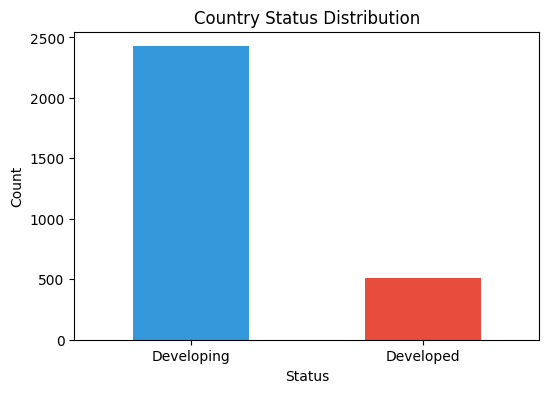

In [16]:
# Status column value counts
print(df['Status'].value_counts())

plt.figure(figsize=(6, 4))
df['Status'].value_counts().plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('Country Status Distribution')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

C:\Users\USSER\AppData\Local\Temp\ipykernel_21720\1446643906.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y='Life expectancy', data=df, palette='Set2')


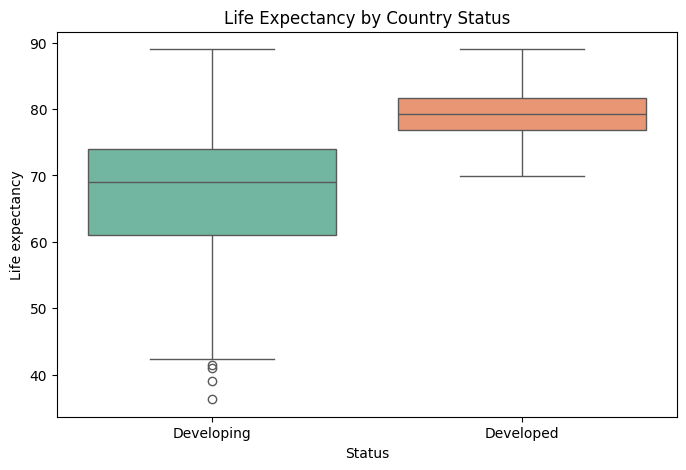

In [17]:
# life expectancy by status
plt.figure(figsize=(8, 5))
sns.boxplot(x='Status', y='Life expectancy', data=df, palette='Set2')
plt.title('Life Expectancy by Country Status')
plt.show()

As expected, developed countries have a significantly higher life expectancy than developing ones.

### 3.4 Correlation Analysis

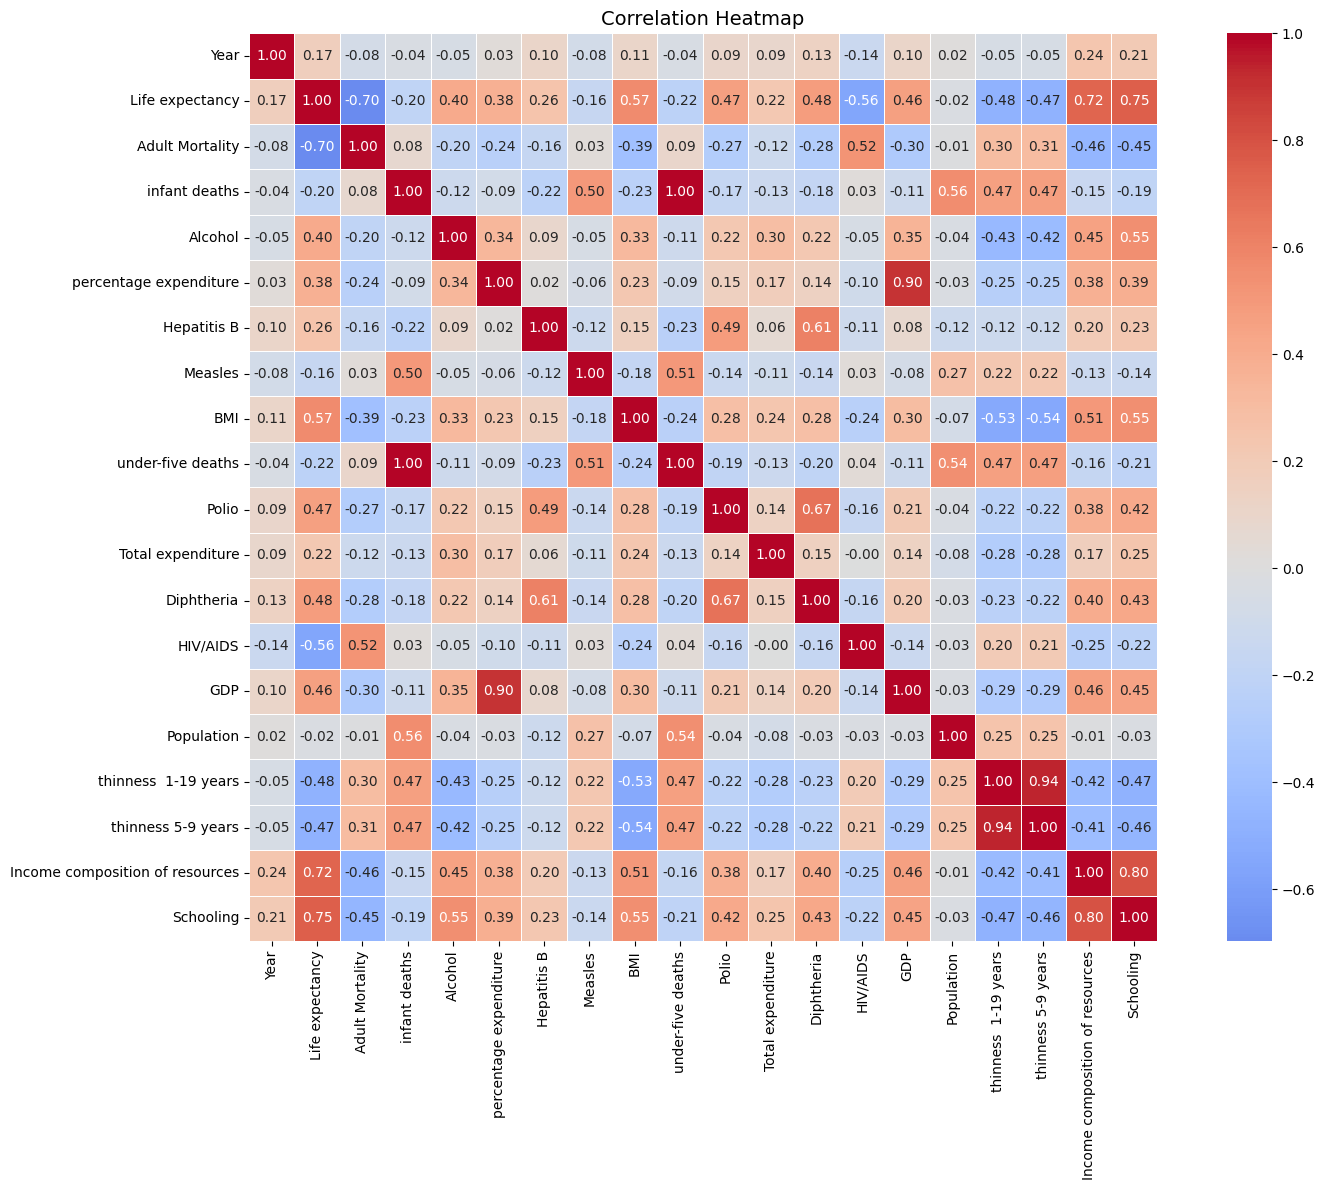

In [18]:
# correlation heatmap
plt.figure(figsize=(16, 12))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
# top correlations with life expectancy
target_corr = corr_matrix['Life expectancy'].drop('Life expectancy').sort_values(ascending=False)
print('Correlations with Life Expectancy:')
print('='*45)
for feat, corr in target_corr.items():
    print(f'{feat:40s} {corr:+.4f}')

Correlations with Life Expectancy:
Schooling                                +0.7520
Income composition of resources          +0.7248
BMI                                      +0.5677
Diphtheria                               +0.4795
Polio                                    +0.4656
GDP                                      +0.4615
Alcohol                                  +0.4049
percentage expenditure                   +0.3819
Hepatitis B                              +0.2568
Total expenditure                        +0.2181
Year                                     +0.1700
Population                               -0.0215
Measles                                  -0.1576
infant deaths                            -0.1966
under-five deaths                        -0.2225
thinness 5-9 years                       -0.4716
thinness  1-19 years                     -0.4772
HIV/AIDS                                 -0.5566
Adult Mortality                          -0.6964


**Key observations from correlation:**
- Schooling, Income composition of resources, and BMI have strong positive correlations
- Adult Mortality and HIV/AIDS have strong negative correlations
- infant deaths and under-five deaths are highly correlated with each other (multicollinearity)

### 3.5 Scatter Plots - Key Features vs Target

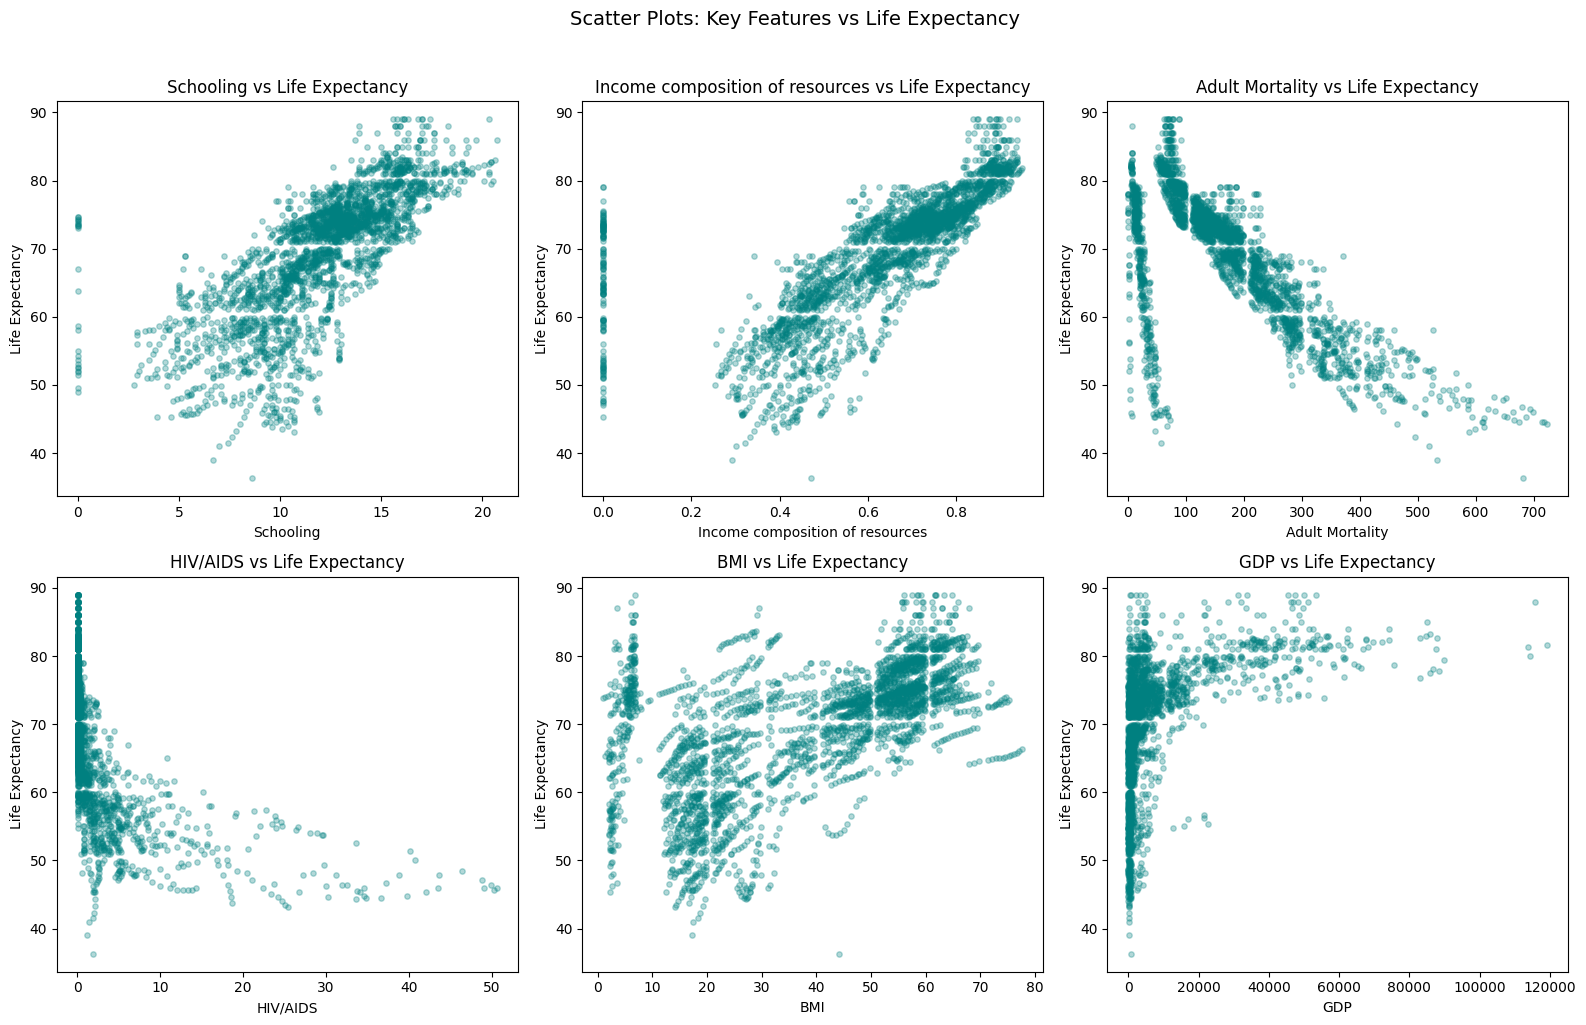

In [20]:
# scatter plots of top features vs life expectancy
top_features = ['Schooling', 'Income composition of resources', 'Adult Mortality', 'HIV/AIDS', 'BMI', 'GDP']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df['Life expectancy'], alpha=0.3, color='teal', s=15)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Life Expectancy')
    axes[i].set_title(f'{feat} vs Life Expectancy')

plt.suptitle('Scatter Plots: Key Features vs Life Expectancy', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

### 4.1 Handling Missing Values

In [21]:
# first let's drop rows where target variable is missing
df = df.dropna(subset=['Life expectancy'])
print(f'Shape after dropping rows with missing target: {df.shape}')

Shape after dropping rows with missing target: (2928, 22)


In [ ]:
# for numerical columns, impute missing values with median (more robust to outliers than mean)
num_cols_to_fill = [col for col in num_cols if col != 'Life expectancy']
num_imputer = SimpleImputer(strategy='median')
df.loc[:, num_cols_to_fill] = num_imputer.fit_transform(df[num_cols_to_fill])

# for categorical columns, impute missing values with the most frequent value
cat_cols_to_fill = df.select_dtypes(include='object').columns.tolist()
if cat_cols_to_fill:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df.loc[:, cat_cols_to_fill] = cat_imputer.fit_transform(df[cat_cols_to_fill])

print(f'\nTotal missing values remaining: {df.isnull().sum().sum()}')
if df.isnull().sum().sum() > 0:
    print(df.isnull().sum()[df.isnull().sum() > 0])


Filled Alcohol with median: 3.77
Filled Hepatitis B with median: 92.00
Filled BMI with median: 43.35
Filled Polio with median: 93.00
Filled Total expenditure with median: 5.75
Filled Diphtheria with median: 93.00
Filled GDP with median: 1764.97
Filled Population with median: 1391756.50
Filled thinness  1-19 years with median: 3.30
Filled thinness 5-9 years with median: 3.40
Filled Income composition of resources with median: 0.68
Filled Schooling with median: 12.30

Total missing values remaining: 2513


C:\Users\USSER\AppData\Local\Temp\ipykernel_21720\3377367976.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(median_val, inplace=True)
C:\Users\USSER\AppData\Local\Temp\ipykernel_21720\3377367976.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using a

### 4.2 Dropping Unnecessary Columns

In [23]:
# dropping 'Country' because it has too many unique values (193 countries)
# it would create way too many dummy variables
df = df.drop('Country', axis=1)
print(f'Shape after dropping Country: {df.shape}')

Shape after dropping Country: (2928, 21)


### 4.3 Encoding Categorical Variables

In [24]:
# encoding 'Status' column (Developing/Developed)
le = LabelEncoder()
df.loc[:, 'Status'] = le.fit_transform(df['Status'])
print('Status encoding:')
print(f'  Classes: {le.classes_}')
print(f'  Encoded: {list(range(len(le.classes_)))}')
print(f'\ndf shape: {df.shape}')
df.head()


Status encoding:
  Classes: ['Developed' 'Developing']
  Encoded: [0, 1]

df shape: (2928, 21)


,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,1,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,1,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013,1,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012,1,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011,1,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


### 4.4 Distribution Check & Skewness Analysis

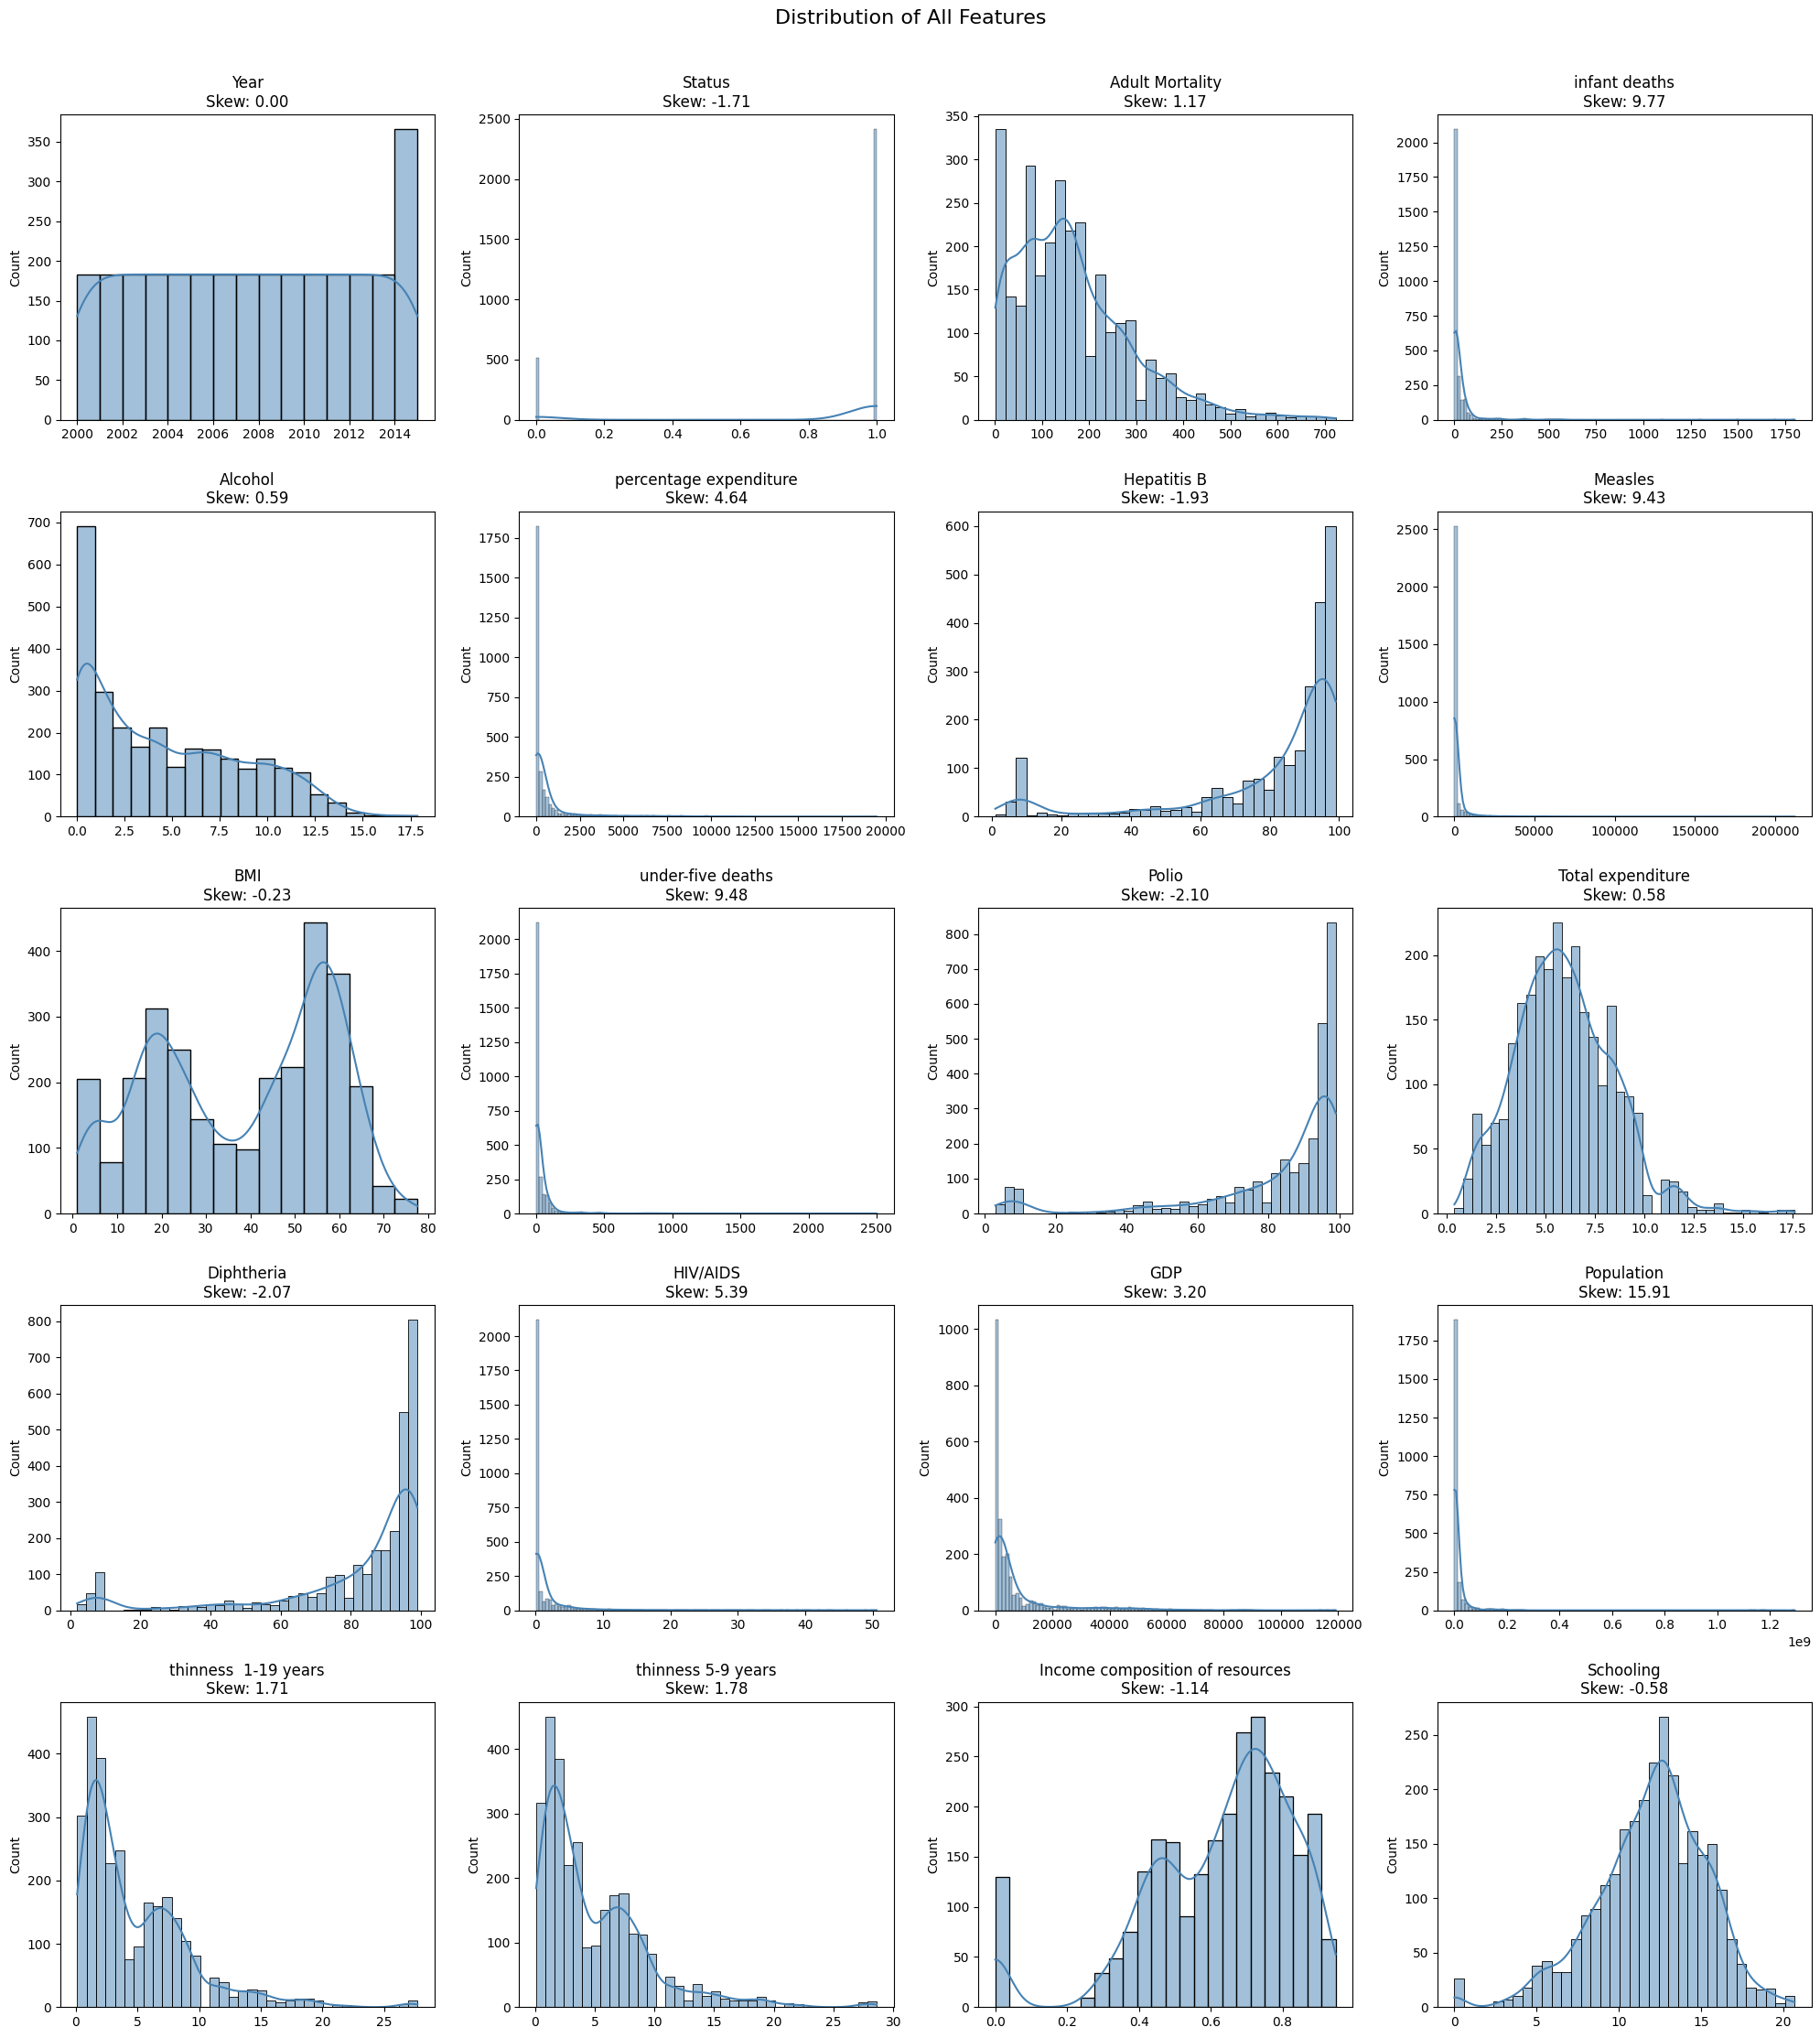

In [25]:
# let's check distributions of all numerical features
num_features = df.select_dtypes(include=np.number).columns.tolist()
num_features.remove('Life expectancy')  # remove target

fig, axes = plt.subplots(5, 4, figsize=(20, 22))
axes = axes.flatten()

for i, col in enumerate(num_features):
    if i < len(axes):
        sns.histplot(x=df[col], kde=True, ax=axes[i], color='steelblue')
        axes[i].set_title(f'{col}\nSkew: {df[col].skew():.2f}')
        axes[i].set_xlabel('')

# hide unused subplots
for j in range(len(num_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of All Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


In [26]:
# checking skewness values
skewness = df[num_features].skew().sort_values(ascending=False)
print('Skewness of features:')
print('='*40)
for feat, skew in skewness.items():
    flag = ' *** HIGHLY SKEWED' if abs(skew) > 2 else (' * moderately skewed' if abs(skew) > 1 else '')
    print(f'{feat:40s} {skew:+.3f}{flag}')

Skewness of features:
Population                               +15.910 *** HIGHLY SKEWED
infant deaths                            +9.771 *** HIGHLY SKEWED
under-five deaths                        +9.480 *** HIGHLY SKEWED
Measles                                  +9.425 *** HIGHLY SKEWED
HIV/AIDS                                 +5.387 *** HIGHLY SKEWED
percentage expenditure                   +4.644 *** HIGHLY SKEWED
GDP                                      +3.203 *** HIGHLY SKEWED
thinness 5-9 years                       +1.777 * moderately skewed
thinness  1-19 years                     +1.711 * moderately skewed
Adult Mortality                          +1.174 * moderately skewed
Alcohol                                  +0.587
Total expenditure                        +0.577
Year                                     +0.000
BMI                                      -0.231
Schooling                                -0.584
Income composition of resources          -1.142 * moderately skewed
Sta

In [27]:
# applying log transformation to highly skewed features (skewness > 2)
# adding 1 to avoid log(0)
highly_skewed = skewness[abs(skewness) > 2].index.tolist()
print(f'Highly skewed features to transform: {highly_skewed}')

for col in highly_skewed:
    # only apply log transform if all values are >= 0
    if df[col].min() >= 0:
        df[col] = np.log1p(df[col])
        print(f'  Log-transformed: {col} (new skew: {df[col].skew():.3f})')
    else:
        print(f'  Skipped {col} (has negative values)')

Highly skewed features to transform: ['Population', 'infant deaths', 'under-five deaths', 'Measles', 'HIV/AIDS', 'percentage expenditure', 'GDP', 'Diphtheria', 'Polio']
  Log-transformed: Population (new skew: -0.551)
  Log-transformed: infant deaths (new skew: 0.698)
  Log-transformed: under-five deaths (new skew: 0.643)
  Log-transformed: Measles (new skew: 0.551)
  Log-transformed: HIV/AIDS (new skew: 2.122)
  Log-transformed: percentage expenditure (new skew: -0.080)
  Log-transformed: GDP (new skew: -0.141)
  Log-transformed: Diphtheria (new skew: -3.154)
  Log-transformed: Polio (new skew: -3.221)


### 4.5 Outlier Detection & Treatment

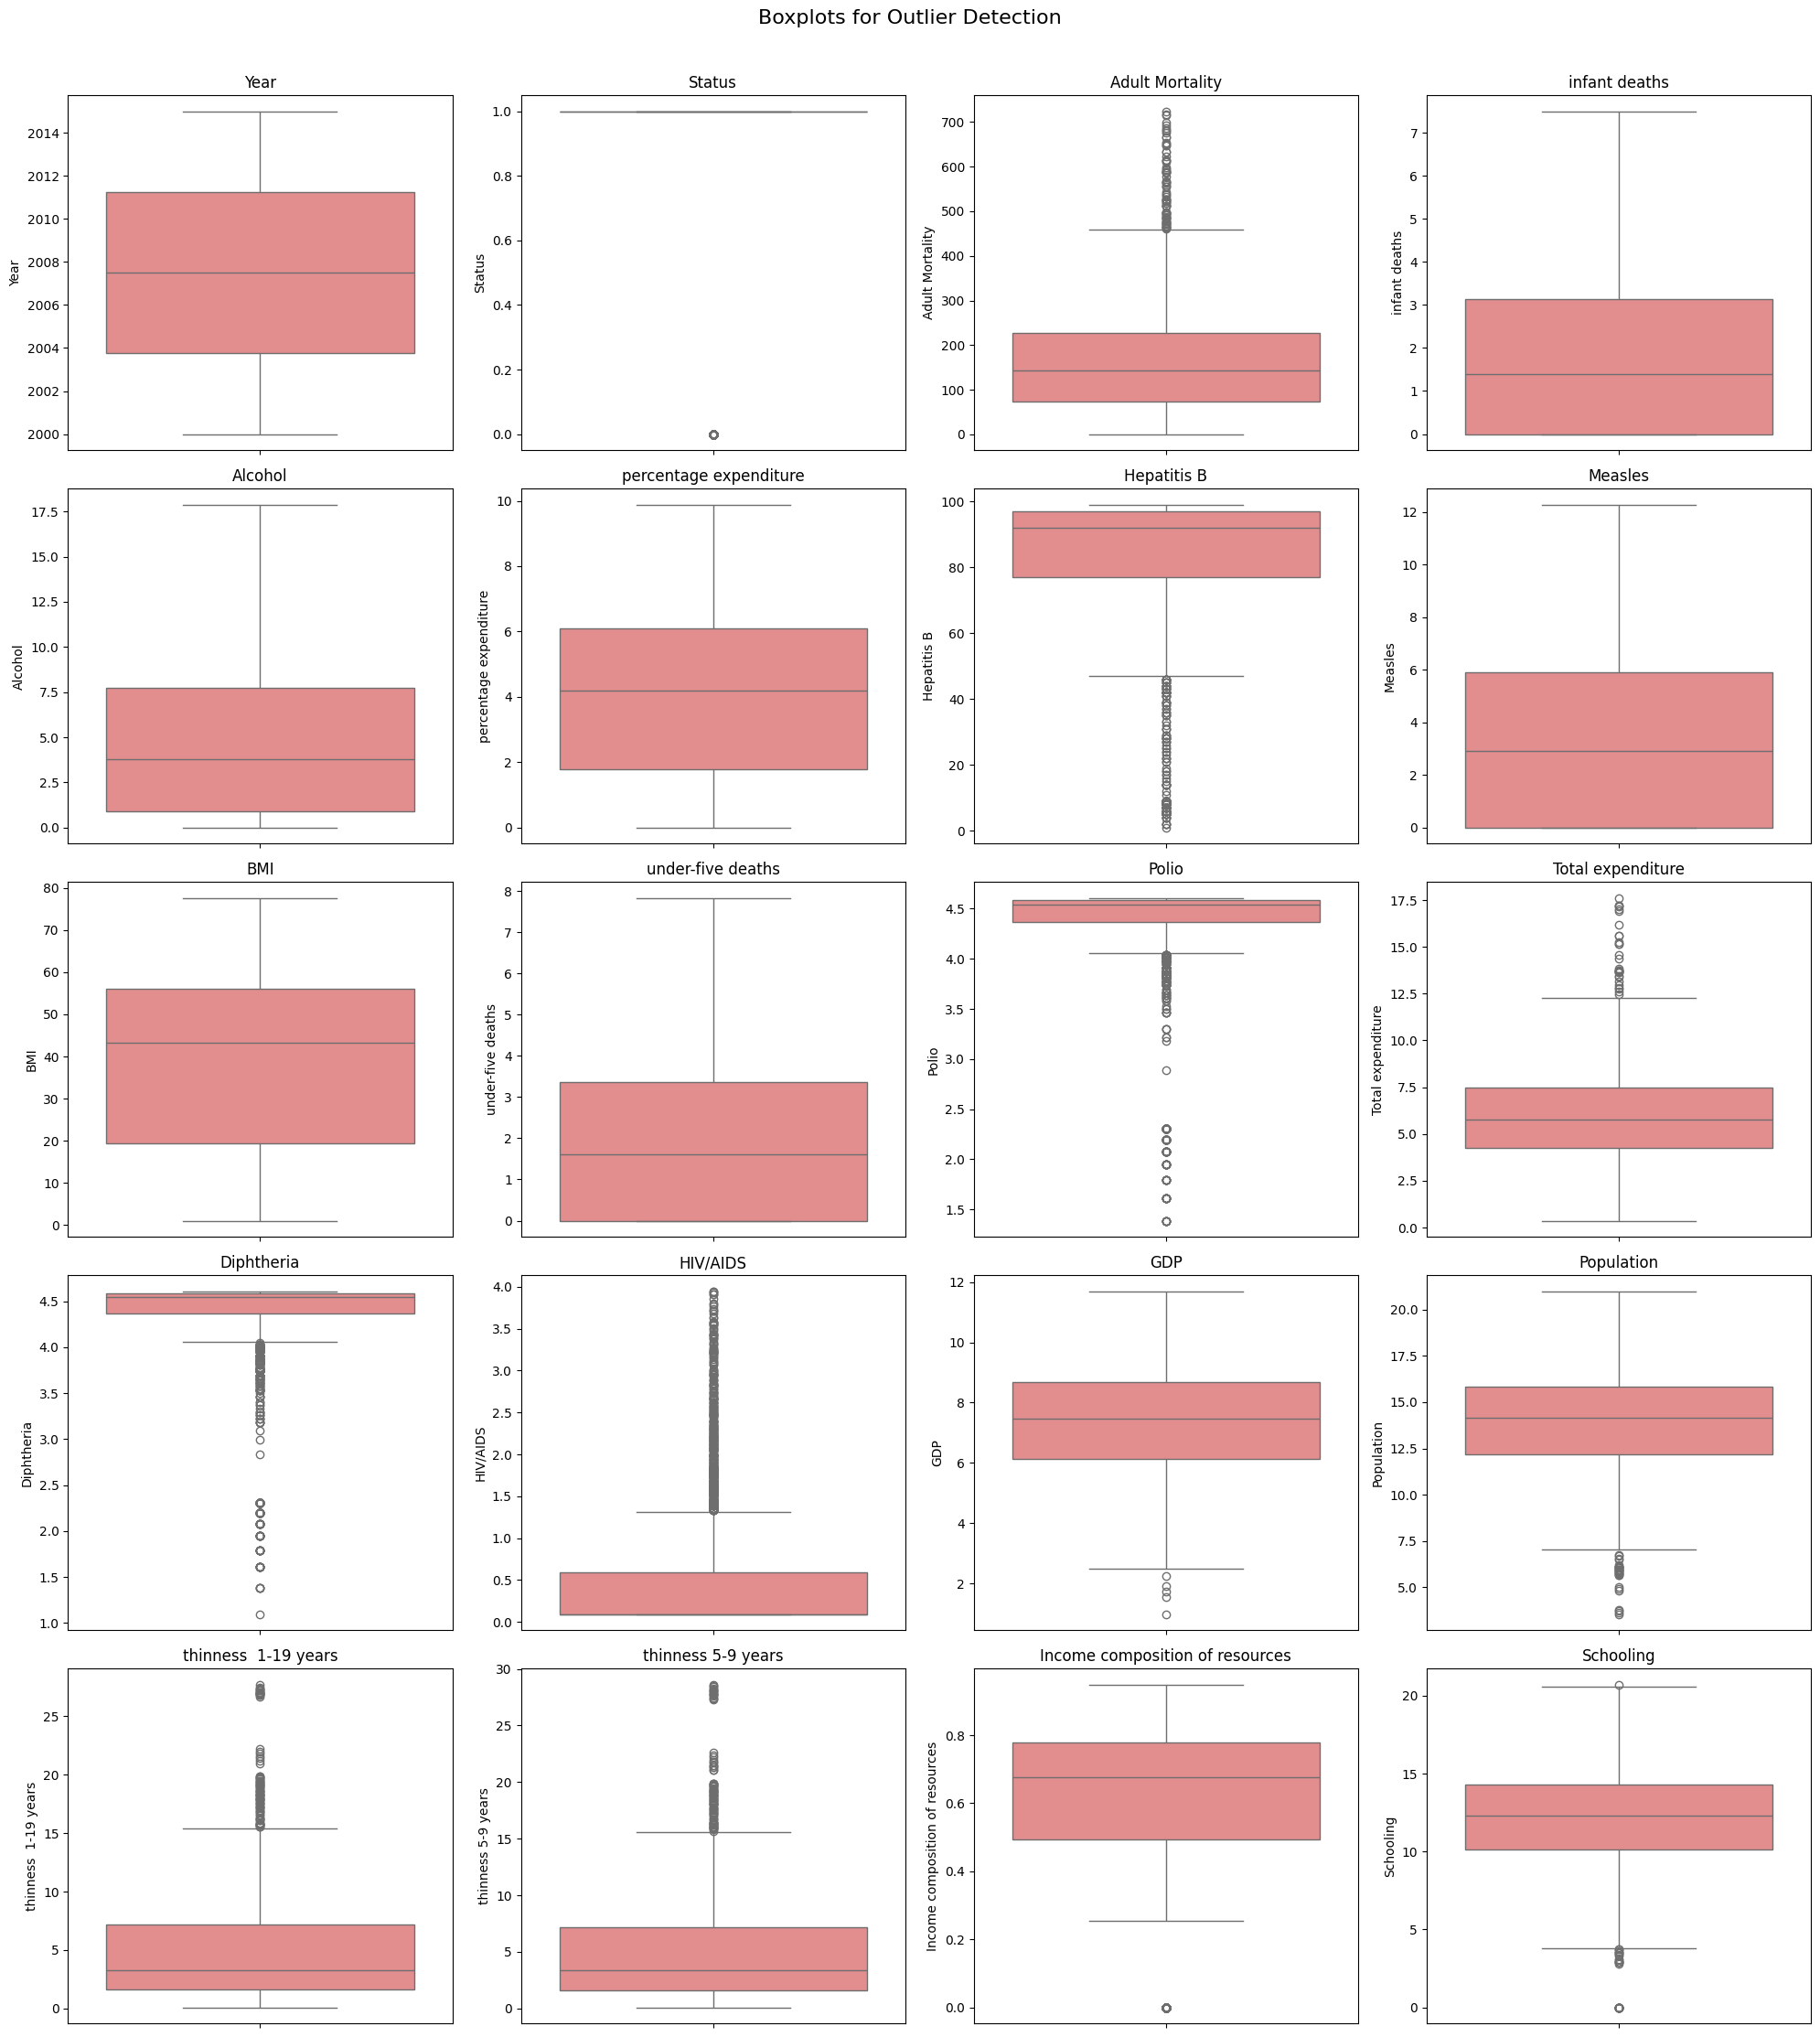

In [28]:
# boxplots to visualize outliers
fig, axes = plt.subplots(5, 4, figsize=(20, 22))
axes = axes.flatten()

for i, col in enumerate(num_features):
    if i < len(axes):
        sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
        axes[i].set_title(col)

for j in range(len(num_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots for Outlier Detection', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

In [29]:
# treating outliers using IQR method - capping at 1.5*IQR
def cap_outliers(dataframe, columns):
    """Cap outliers using IQR method"""
    for col in columns:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers_count = ((dataframe[col] < lower) | (dataframe[col] > upper)).sum()
        if outliers_count > 0:
            dataframe[col] = dataframe[col].clip(lower=lower, upper=upper)
            print(f'{col}: {outliers_count} outliers capped')
    return dataframe

# apply to numerical features (excluding binary columns like Status)
cols_to_cap = [col for col in num_features if df[col].nunique() > 2]
df = cap_outliers(df, cols_to_cap)
print('\nOutlier treatment done!')

Adult Mortality: 82 outliers capped
Hepatitis B: 252 outliers capped
Polio: 331 outliers capped
Total expenditure: 30 outliers capped
Diphtheria: 331 outliers capped
HIV/AIDS: 421 outliers capped
GDP: 5 outliers capped
Population: 30 outliers capped
thinness  1-19 years: 89 outliers capped
thinness 5-9 years: 97 outliers capped
Income composition of resources: 130 outliers capped
Schooling: 42 outliers capped

Outlier treatment done!


## 5. Feature Scaling & Train-Test Split

In [30]:
# separating features and target
X = df.drop('Life expectancy', axis=1)
y = df['Life expectancy']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')

Features shape: (2928, 20)
Target shape: (2928,)


In [31]:
# train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')

Training set: (2342, 20)
Test set: (586, 20)


In [32]:
# feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# converting back to dataframe for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print('Feature scaling done!')
X_train_scaled.head()

Feature scaling done!


,Year,Status,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
2268,0.966331,0.457259,-0.322716,-0.650013,1.184678,0.963806,0.768946,-1.026263,1.009532,-0.703222,0.513264,1.656663,0.402598,-0.644172,0.636948,-0.171177,-0.661130,-0.661262,0.685429,0.605958
1680,-1.205595,0.457259,0.135555,-1.065746,-0.115380,0.706795,0.238598,-1.026263,-0.581094,-1.091010,0.219991,-0.676215,0.223801,-0.644172,0.444831,-0.843497,0.788091,0.776829,0.266014,0.142960
2785,0.097560,0.457259,1.838937,1.652799,-0.289051,-1.476956,0.120743,1.466120,-0.920162,1.669628,0.279942,-0.688602,0.101222,1.974108,NaN,NaN,0.638171,0.628061,NaN,NaN
2512,0.097560,-2.186942,-0.876099,-1.065746,0.569383,1.845785,NaN,-0.028133,0.919779,-1.091010,0.791335,1.384150,0.798090,-0.644172,1.865727,0.806242,-0.861022,-0.859619,1.334523,1.130688
1090,1.617908,0.457259,0.965629,-0.100444,NaN,-1.476956,0.179670,0.516826,-0.586081,-0.002352,0.159362,NaN,0.162860,1.974108,-0.570623,-0.707864,0.588198,0.553677,-1.042160,-0.875635


## 6. Model Building & Evaluation

We'll train multiple regression models and compare their performances using R², MSE, RMSE, and MAE.

In [33]:
# helper function to evaluate models
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Train model, predict, and return metrics"""
    model.fit(X_train, y_train)
    
    # predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # metrics on test set
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_test_pred)
    
    # cross validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    
    print(f'\n{"="*50}')
    print(f'  {model_name}')
    print(f'{"="*50}')
    print(f'  Train R² Score: {r2_train:.4f}')
    print(f'  Test R² Score:  {r2_test:.4f}')
    print(f'  MSE:            {mse:.4f}')
    print(f'  RMSE:           {rmse:.4f}')
    print(f'  MAE:            {mae:.4f}')
    print(f'  CV Mean R²:     {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
    
    # check for overfitting
    overfit_gap = r2_train - r2_test
    if overfit_gap > 0.1:
        print(f'  ⚠ Possible overfitting (train-test gap: {overfit_gap:.4f})')
    else:
        print(f'  ✓ No significant overfitting (gap: {overfit_gap:.4f})')
    
    return {
        'Model': model_name,
        'Train R2': r2_train,
        'Test R2': r2_test,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'CV Mean R2': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Overfit Gap': overfit_gap
    }

In [34]:
# storing results for comparison
results = []

### 6.1 Linear Regression

In [35]:
lr_model = LinearRegression()
lr_results = evaluate_model(lr_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Linear Regression')
results.append(lr_results)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

### 6.2 Decision Tree Regressor

In [ ]:
# using max_depth to prevent overfitting
dt_model = DecisionTreeRegressor(max_depth=8, min_samples_split=10, min_samples_leaf=5, random_state=42)
dt_results = evaluate_model(dt_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Decision Tree')
results.append(dt_results)

### 6.3 Random Forest Regressor

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_split=5,
                                  min_samples_leaf=3, random_state=42, n_jobs=-1)
rf_results = evaluate_model(rf_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Random Forest')
results.append(rf_results)

### 6.4 Support Vector Regressor (SVR)

In [ ]:
# SVR works best with scaled data which we already have
svr_model = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_results = evaluate_model(svr_model, X_train_scaled, X_test_scaled, y_train, y_test, 'SVR')
results.append(svr_results)

### 6.5 K-Nearest Neighbors Regressor

In [ ]:
knn_model = KNeighborsRegressor(n_neighbors=7, weights='distance', metric='minkowski')
knn_results = evaluate_model(knn_model, X_train_scaled, X_test_scaled, y_train, y_test, 'KNN')
results.append(knn_results)

### 6.6 XGBoost Regressor

In [ ]:
xgb_model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                          subsample=0.8, colsample_bytree=0.8,
                          reg_alpha=0.1, reg_lambda=1.0,
                          random_state=42, verbosity=0)
xgb_results = evaluate_model(xgb_model, X_train_scaled, X_test_scaled, y_train, y_test, 'XGBoost')
results.append(xgb_results)

## 7. Model Comparison

In [ ]:
# creating comparison dataframe
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('Test R2', ascending=False).reset_index(drop=True)

# formatting for display
comparison_df_display = comparison_df.copy()
comparison_df_display['Train R2'] = comparison_df_display['Train R2'].round(4)
comparison_df_display['Test R2'] = comparison_df_display['Test R2'].round(4)
comparison_df_display['MSE'] = comparison_df_display['MSE'].round(4)
comparison_df_display['RMSE'] = comparison_df_display['RMSE'].round(4)
comparison_df_display['MAE'] = comparison_df_display['MAE'].round(4)
comparison_df_display['CV Mean R2'] = comparison_df_display['CV Mean R2'].round(4)
comparison_df_display['CV Std'] = comparison_df_display['CV Std'].round(4)
comparison_df_display['Overfit Gap'] = comparison_df_display['Overfit Gap'].round(4)

print('\n' + '='*80)
print('               MODEL COMPARISON TABLE (sorted by Test R²)')
print('='*80)
comparison_df_display

In [ ]:
# visualizing model comparison - R2 scores
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R2 score comparison
x_pos = range(len(comparison_df))
width = 0.35

axes[0].bar([p - width/2 for p in x_pos], comparison_df['Train R2'], width, label='Train R²', color='#3498db', alpha=0.8)
axes[0].bar([p + width/2 for p in x_pos], comparison_df['Test R2'], width, label='Test R²', color='#e74c3c', alpha=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Train vs Test R² Score Comparison')
axes[0].legend()
axes[0].set_ylim(0, 1.05)

# RMSE comparison
axes[1].bar(comparison_df['Model'], comparison_df['RMSE'], color='#2ecc71', alpha=0.8)
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE Comparison (lower is better)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# cross validation R2 comparison
plt.figure(figsize=(10, 6))
plt.bar(comparison_df['Model'], comparison_df['CV Mean R2'], 
        yerr=comparison_df['CV Std'], capsize=5, color='#9b59b6', alpha=0.8)
plt.ylabel('Cross-Validation R² Score')
plt.title('5-Fold Cross Validation R² Score (with std dev)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 8. Overfitting Analysis

In [ ]:
# overfitting check - comparing train vs test R2
plt.figure(figsize=(10, 6))
plt.bar(comparison_df['Model'], comparison_df['Overfit Gap'], 
        color=['red' if g > 0.1 else 'green' for g in comparison_df['Overfit Gap']], alpha=0.7)
plt.axhline(y=0.1, color='red', linestyle='--', label='Overfitting threshold (0.1)')
plt.ylabel('Train R² - Test R² (Gap)')
plt.title('Overfitting Check: Train-Test R² Gap')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

print('\nOverfitting Summary:')
for _, row in comparison_df.iterrows():
    status = '⚠ OVERFITTING' if row['Overfit Gap'] > 0.1 else '✓ OK'
    print(f"  {row['Model']:20s} Gap: {row['Overfit Gap']:.4f}  {status}")

## 9. Feature Importance (Best Model)

In [ ]:
# using Random Forest feature importances
feature_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_imp = feature_imp.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feature_imp.plot(kind='barh', color='teal')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
# XGBoost feature importance
xgb_imp = pd.Series(xgb_model.feature_importances_, index=X.columns)
xgb_imp = xgb_imp.sort_values(ascending=True)

plt.figure(figsize=(10, 8))
xgb_imp.plot(kind='barh', color='darkorange')
plt.title('Feature Importance (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 10. Actual vs Predicted Plot (Best Model)

In [ ]:
# plotting actual vs predicted for top 3 models
best_models = {
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'Linear Regression': lr_model
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test_scaled)
    axes[i].scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=20)
    
    # perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    axes[i].set_xlabel('Actual Life Expectancy')
    axes[i].set_ylabel('Predicted Life Expectancy')
    r2 = r2_score(y_test, y_pred)
    axes[i].set_title(f'{name}\nR² = {r2:.4f}')

plt.suptitle('Actual vs Predicted Values', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Residual Analysis (Best Model)

In [ ]:
# residual plot for the best model
best_model = rf_model  # assuming RF is the best based on results
y_pred_best = best_model.predict(X_test_scaled)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# residuals vs predicted
axes[0].scatter(y_pred_best, residuals, alpha=0.5, color='purple', s=20)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

# distribution of residuals
sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].set_xlabel('Residual Value')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

print(f'Mean Residual: {residuals.mean():.4f}')
print(f'Std Residual: {residuals.std():.4f}')

Residuals look approximately normally distributed and centered around 0 which is a good sign. The model predictions are reasonably unbiased.

## 12. Final Comparison Table

In [ ]:
# final nice comparison table
final_table = comparison_df[['Model', 'Train R2', 'Test R2', 'RMSE', 'MAE', 'CV Mean R2', 'Overfit Gap']].copy()
final_table.columns = ['Model', 'Train R²', 'Test R²', 'RMSE', 'MAE', 'CV R² (mean)', 'Overfit Gap']
final_table = final_table.sort_values('Test R²', ascending=False).reset_index(drop=True)
final_table.index = final_table.index + 1  # start from 1
final_table.index.name = 'Rank'

print('\n' + '='*85)
print('                    FINAL MODEL COMPARISON RESULTS')
print('='*85)
final_table

In [ ]:
# identify best model
best = comparison_df.iloc[0]
print(f"\n🏆 Best Model: {best['Model']}")
print(f"   Test R² Score: {best['Test R2']:.4f}")
print(f"   RMSE: {best['RMSE']:.4f}")
print(f"   MAE: {best['MAE']:.4f}")
print(f"   Cross-Validation R²: {best['CV Mean R2']:.4f}")